In [3]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import metpy.calc as mpcalc
from metpy.units import units

In [22]:
with open('/home/annierosen16/master_w_sp_2001_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [11]:
# sfc_term_df = pd.DataFrame(all_surface_tups, columns=['time','lat','lon','zonal_sfc_term', 'meridional_sfc_term'])

sfc_term_df = pd.read_pickle("/home/annierosen16/sfc_term_df_2001_2025.pkl")

In [15]:
sfc_term_df['date'] = pd.to_datetime(sfc_term_df['time']).dt.date

In [16]:
diurnal_sfc_term_df = (
    
    sfc_term_df
    
    .groupby(['date', 'lat', 'lon'])[['zonal_sfc_term', 'meridional_sfc_term']]
    
    .agg(lambda x: list(x))
    
    .reset_index()
    
    .rename(columns={
        'zonal_sfc_term': 'diurnal_zonal_sfc_term',
        'meridional_sfc_term': 'diurnal_meridional_sfc_term'
    
    })
)

In [20]:
diurnal_sfc_term_df = diurnal_sfc_term_df.rename(columns={'lat': 'latitude', 'lon': 'longitude'})

In [23]:
master['date'] = pd.to_datetime(master['date'])

diurnal_sfc_term_df['date'] = pd.to_datetime(diurnal_sfc_term_df['date'])

master_sfc_term = master.merge(diurnal_sfc_term_df[['date', 'latitude', 'longitude', 'diurnal_zonal_sfc_term','diurnal_meridional_sfc_term']],
    on=['date', 'latitude', 'longitude'],
    how='left'
)

In [32]:
predryapes = master_sfc_term[master_sfc_term['predryape']==True]

prewetapes = master_sfc_term[master_sfc_term['prewetape']==True]

In [33]:
predryapes['diurnal_zonal_sfc_term'] = predryapes['diurnal_zonal_sfc_term'].apply(np.array)

predryapes['diurnal_meridional_sfc_term'] = predryapes['diurnal_meridional_sfc_term'].apply(np.array)

prewetapes['diurnal_zonal_sfc_term'] = prewetapes['diurnal_zonal_sfc_term'].apply(np.array)

prewetapes['diurnal_meridional_sfc_term'] = prewetapes['diurnal_meridional_sfc_term'].apply(np.array)

/tmp/ipykernel_70332/1840701541.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predryapes['diurnal_zonal_sfc_term'] = predryapes['diurnal_zonal_sfc_term'].apply(np.array)
/tmp/ipykernel_70332/1840701541.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predryapes['diurnal_meridional_sfc_term'] = predryapes['diurnal_meridional_sfc_term'].apply(np.array)
/tmp/ipykernel_70332/1840701541.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

In [34]:
predryapes['diurnal_sfc_term'] = (predryapes['diurnal_zonal_sfc_term'] + predryapes['diurnal_meridional_sfc_term']) 

prewetapes['diurnal_sfc_term'] = (prewetapes['diurnal_zonal_sfc_term'] + prewetapes['diurnal_meridional_sfc_term'])

/tmp/ipykernel_70332/3507802832.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predryapes['diurnal_sfc_term'] = (predryapes['diurnal_zonal_sfc_term'] + predryapes['diurnal_meridional_sfc_term'])
/tmp/ipykernel_70332/3507802832.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prewetapes['diurnal_sfc_term'] = (prewetapes['diurnal_zonal_sfc_term'] + prewetapes['diurnal_meridional_sfc_term'])


In [35]:
dry_stacked = np.stack(predryapes['diurnal_sfc_term'].values)

diurnal_sfc_term_dry = dry_stacked.mean(axis=0)

wet_stacked = np.stack(prewetapes['diurnal_sfc_term'].values)

diurnal_sfc_term_wet = wet_stacked.mean(axis=0)

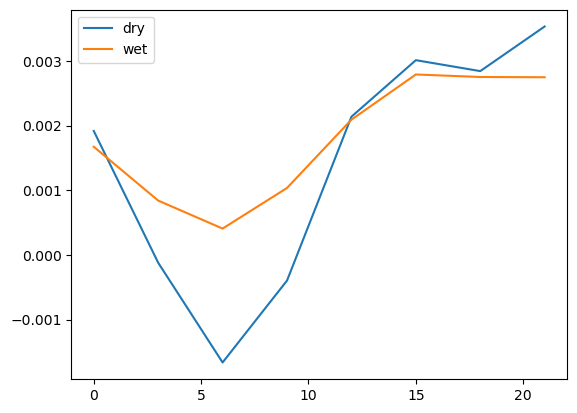

In [36]:
plt.plot(range(0,24)[::3], diurnal_sfc_term_dry, label='dry')

plt.plot(range(0,24)[::3], diurnal_sfc_term_wet, label='wet')

plt.legend()

plt.show()

In [37]:
with open('/home/annierosen16/diurnal_sfc_term_2001_2025_preapes.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': diurnal_sfc_term_dry,
        
        'wet': diurnal_sfc_term_wet
    
    }, f)